#### **Importation des bibliothèques**

In [2]:
# Utilitaires de base
import builtins
import pandas as pd
import re
# Suivi des expriences (MLflow & DagsHub)
import dagshub
import mlflow

# Scikit-Learn : Sparation des donnes et mtriques d'valuation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    f1_score, 
    fbeta_score, 
    precision_score, 
    recall_score
)

# TensorFlow / Keras : Cration et entranement du modle Deep Learning
import tensorflow as tf

#### **DagsHub & MLflow Init**

In [3]:

# Initialisation de la connexion DagsHub avec les identifiants de votre dépôt et activation du mode MLflow
# PATCH WINDOWS : Force l'utilisation de l'encodage UTF-8 lors de l'écriture des fichiers.
# Ceci corrige l'erreur "charmap codec can't encode characters" causée par le nouveau format d'affichage (summary) de Keras 3
_original_open = builtins.open
def _utf8_open(*args, **kwargs):
    mode = kwargs.get('mode', args[1] if len(args) > 1 else 'r')
    if 'b' not in mode and 'encoding' not in kwargs:
        kwargs['encoding'] = 'utf-8'
    return _original_open(*args, **kwargs)
builtins.open = _utf8_open

dagshub.init(repo_owner='Oscar-AS', repo_name='disaster-tweets-project', mlflow=True)

# Définition du nom du dossier (expérience) dans MLflow où toutes nos métriques seront classées
mlflow.set_experiment("Disaster_Tweets")

# Affichage d'un message console pour confirmer que le tracking est bien connecté
print("MLflow activé avec succès sur DagsHub !")


Accessing as Oscar-AS

Initialized MLflow to track repo "Oscar-AS/disaster-tweets-project"

Repository Oscar-AS/disaster-tweets-project initialized!

MLflow activé avec succès sur DagsHub !


#### Importation des données


In [4]:
# Chargement des données
# Lecture du fichier CSV depuis le dossier Base et stockage dans la variable 'df'
df = pd.read_csv("../Base/tweets.csv")



#### Nettoyage

In [5]:
def cleaning_simple(data):
    text = str(data)  # convertir en texte pour éviter les erreurs avec les valeurs manquantes
    
    text = re.sub(r'https?://\S+|www\.\S+|http?://\S+', ' ', text)  # supprimer les URLs
    
    text = re.sub(r'<.*?>', ' ', text)  # supprimer les balises HTML
    
    text = re.sub("["
                  u"\U0001F600-\U0001F64F"
                  u"\U0001F300-\U0001F5FF"
                  u"\U0001F680-\U0001F6FF"
                  u"\U0001F1E0-\U0001F1FF"
                  u"\U00002702-\U000027B0"
                  u"\U000024C2-\U0001F251"
                  "]+", ' ', text)  # supprimer les émojis et symboles
    
    text = re.sub(r'@\S+', ' ', text)  # supprimer les mentions @user
    
    text = re.sub(r'#', '', text)  # supprimer le symbole # mais garder le mot
    
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # garder uniquement les lettres et les espaces
    
    text = text.lower()  # convertir en minuscules
    
    text = re.sub(r'\s+', ' ', text).strip()  # supprimer les espaces multiples
    
    return text

In [6]:
df["text"] = df["text"].apply(cleaning_simple)

In [7]:
df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,communal violence in bhainsa telangana stones ...,1
1,1,ablaze,NaN,telangana section has been imposed in bhainsa ...,1
2,2,ablaze,New York City,arsonist sets cars ablaze at dealership,1
3,3,ablaze,"Morgantown, WV",arsonist sets cars ablaze at dealership,1
4,4,ablaze,NaN,lord jesus your love brings freedom and pardon...,0


#### **Séparation des données**

In [8]:
# Séparation Train/Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# Affiche dans la console le nombre de tweets utilisés pour l'entraînement
print(f"Taille de l'entraînement : {len(X_train)}")
# Affiche dans la console le nombre de tweets gardés pour le test
print(f"Taille du test : {len(X_test)}")

Taille de l'entraînement : 9096
Taille du test : 2274


#### **Modèles Transformers via Hugging Face**

In [9]:
# Import de l'objet Dataset de Hugging Face
from datasets import Dataset
# Import de evaluate pour calculer de façon standardisée les métriques d'évaluation
# Import de NumPy
import numpy as np

# Transformation de notre DataFrame d'entraînement Pandas en un objet "Dataset" ultra-optimisé de Hugging Face
hf_train = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train}))
# Transformation de notre DataFrame de test Pandas
hf_test = Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test}))

# Importation de scikit-learn pour calculer facilement le F2-Score et les métriques par classe

# Fonction exécutée à la fin de chaque Epoch par le Trainer pour calculer le score
def compute_metrics(eval_pred):
    # Séparation des probabilités prédites (logits) et des vraies réponses (labels)
    logits, labels = eval_pred
    # L'argmax récupère la classe ayant reçu la plus forte probabilité (0 ou 1)
    predictions = np.argmax(logits, axis=-1)
    
    # Précision et Rappel par classe
    precision_cls = precision_score(labels, predictions, average=None)
    recall_cls = recall_score(labels, predictions, average=None)
    
    # Calcul des métriques globales
    f1 = f1_score(labels, predictions, average="macro")
    f2 = fbeta_score(labels, predictions, beta=2, average="macro")
    accuracy = accuracy_score(labels, predictions)
    
    # Retourner toutes les métriques pour le suivi MLflow (le Trainer ajoutera automatiquement le préfixe "eval_")
    return {
        "f1_macro": f1,
        "f2_score": f2,
        "precision_class_0": precision_cls[0],
        "precision_class_1": precision_cls[1],
        "recall_class_0": recall_cls[0],
        "recall_class_1": recall_cls[1],
        "accuracy": accuracy
    }

# Importation du système d'exploitation
import os
# Paramétrage de la variable d'environnement qui indique à Hugging Face dans quel dossier MLflow il doit écrire
os.environ["MLFLOW_EXPERIMENT_NAME"] = "Disaster_Tweets_Niveau_3_et_4"
# Augmente le délai à 10 minutes pour éviter les erreurs d'upload sur DagsHub
os.environ["MLFLOW_HTTP_REQUEST_TIMEOUT"] = "600"


In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

def train_hf_model(model_id, run_name, batch_size=16, epochs=3):
    print(f"========== Début : {model_id} ==========")
    
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    
    def tokenize_function(examples):
        # ✅ OPTIMISATION 1 : max_length 128 → 64 (tweets courts, -50% temps)
        return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)
    
    tokenized_train = hf_train.map(tokenize_function, batched=True)
    tokenized_test = hf_test.map(tokenize_function, batched=True)
    
    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)
    
    training_args = TrainingArguments(
        output_dir=f"./results_{run_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        report_to="mlflow",
        run_name=run_name,
        
        # ✅ OPTIMISATION 2 : fp16 — divise la VRAM par 2, +40% vitesse
        fp16=True,
        
        # ✅ OPTIMISATION 3 : sélection sur F2 et non sur la loss
        metric_for_best_model="eval_f2_score",
        greater_is_better=True,
        
        # ✅ OPTIMISATION 4 : warmup pour protéger les poids pré-entraînés
        warmup_ratio=0.1,
        
        # ✅ OPTIMISATION 5 : chargement data en parallèle
        dataloader_num_workers=4,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics,
        # ✅ OPTIMISATION 6 : arrêt automatique si pas d'amélioration
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    
    trainer.train()

    # --- NOUVEAU : Sauvegarde locale de sécurité ---
    save_path = f"./best_model_{run_name}"
    print(f"Sauvegarde du modèle en local dans {save_path}...")
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)


    try:
        print("Tentative d'envoi du modèle vers DagsHub...")
        components = {"model": trainer.model, "tokenizer": tokenizer}
        mlflow.transformers.log_model(
            transformers_model=components, 
            artifact_path="model",
            task="text-classification"
        )
        print("✅ Modèle enregistré avec succès sur DagsHub !")
        # Tente d'enregistrer le modèle HuggingFace dans MLflow pour la mise en production
    except Exception as e:
        print(f"⚠️ L'envoi vers DagsHub a échoué (souvent dû à la taille du fichier) : {e}")
        print(f"Pas de souci, ton modèle est bien sauvegardé ici : {save_path}")
        print("Avertissement: L'enregistrement du modèle Transformers dans MLflow a échoué:", e)
    
    # Force MLflow à fermer proprement la session de suivi de ce run
    mlflow.end_run()
    # Affiche la fin dans la console
    print(f"========== Fin de l'entraînement pour {model_id} ==========\n")
    return trainer, tokenized_test



#### **Modèle DistilBERT**

##### **Description du modèle**
DistilBERT est une version "compressée" du modèle BERT original de Google.

##### **Explication du fonctionnement**
Il utilise une technique appelée **Distillation de Connaissance** : on prend un énorme modèle (BERT) qui sert de "Professeur", et on entraîne un petit modèle ("l'Élève", DistilBERT) à reproduire les réponses du professeur. Le résultat est un modèle 40% plus petit, 60% plus rapide, mais qui conserve 97% des capacités de compréhension du langage de BERT.


In [ ]:
# Appel de notre super-fonction pour entraîner DistilBERT. 
# Comme il est très rapide, on peut s'autoriser de faire 3 epochs au lieu de 2.
trainer, tokenized_test = train_hf_model(model_id="distilbert-base-uncased", run_name="DistilBERT", epochs=3)



========== Début : distilbert-base-uncased ==========


Map:   0%|          | 0/9096 [00:00<?, ? examples/s]

Map:   0%|          | 0/2274 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning

Epoch,Training Loss,Validation Loss


#### Charger le modele

In [11]:

# Chemin vers la sauvegarde locale
local_model_path = "./best_model_DistilBERT"

# Chargement manuel du tokenizer et du modèle
tokenizer = AutoTokenizer.from_pretrained(local_model_path)
model = AutoModelForSequenceClassification.from_pretrained(local_model_path)

# Re-création de l'objet Trainer (pour pouvoir utiliser trainer.predict sur tokenized_test)
trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics
)

print("Modèle DistilBERT chargé manuellement avec succès depuis le stockage local.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Modèle DistilBERT chargé manuellement avec succès depuis le stockage local.


In [ ]:
import mlflow.transformers

# 1. On s'assure d'utiliser le bon dossier d'expérience
mlflow.set_experiment("Disaster_Tweets")

# 2. On lance un run manuel pour l'enregistrement
with mlflow.start_run(run_name="DistilBERT_Manual_Upload"):
    print("Tentative d'envoi manuel du modèle vers DagsHub (cela peut prendre quelques minutes)...")
    
    # Préparation des composants du modèle
    components = {
        "model": model, 
        "tokenizer": tokenizer
    }
    
    # Enregistrement du modèle
    mlflow.transformers.log_model(
        transformers_model=components,
        artifact_path="model",
        task="text-classification"
    )
    
    print("✅ Modèle enregistré avec succès sur MLflow/DagsHub !")


2026/05/08 19:32:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tentative d'envoi manuel du modèle vers DagsHub (cela peut prendre quelques minutes)...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026/05/08 19:33:00 WARNING mlflow.transformers: The model card could not be retrieved from the hub due to Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './best_model_DistilBERT'.
2026/05/08 19:33:00 WARNING mlflow.transformers: Unable to find license information for this model. Please verify permissible usage for the model you are storing prior to use.
2026/05/08 19:33:00 WARNING mlflow.utils.environment: On Windows, timeout is not supported for model requirement inference. Therefore, the operation is not bound by a timeout and may hang indefinitely. If it hangs, please consider specifying the signature manually.


#### Métric

In [ ]:
# 1. Obtenir les prédictions (si non déjà fait)
try:
    _ = logits
    _ = y_true
except NameError:
    preds = trainer.predict(tokenized_test)
    logits = preds.predictions
    y_true = preds.label_ids

# 2. Tableau récapitulatif des métriques du modèle
y_pred = np.argmax(logits, axis=-1)
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
f2_class = fbeta_score(y_true, y_pred, beta=2, average=None, zero_division=0)
f2_macro = fbeta_score(y_true, y_pred, beta=2, average="macro", zero_division=0)
f2_weighted = fbeta_score(y_true, y_pred, beta=2, average="weighted", zero_division=0)

metrics_table = (
    pd.DataFrame(report)
    .transpose()
    .rename(index={
        "0": "Non disaster",
        "1": "Disaster",
        "accuracy": "Accuracy",
        "macro avg": "Macro average",
        "weighted avg": "Weighted average",
    })
)

metrics_table["f2-score"] = pd.NA
metrics_table.loc["Non disaster", "f2-score"] = f2_class[0]
metrics_table.loc["Disaster", "f2-score"] = f2_class[1]
metrics_table.loc["Macro average", "f2-score"] = f2_macro
metrics_table.loc["Weighted average", "f2-score"] = f2_weighted

metrics_table = metrics_table[["precision", "recall", "f1-score", "f2-score", "support"]]
metrics_table.round(3)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Obtenir les prédictions et probabilités
preds = trainer.predict(tokenized_test)
logits = preds.predictions
y_probs = tf.nn.softmax(logits, axis=-1).numpy()[:, 1]
y_true = preds.label_ids

# 2. Courbe Précision-Rappel
precision, recall, _ = precision_recall_curve(y_true, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Précision-Rappel (DistilBERT)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Courbe de Lift
data = pd.DataFrame({'y_true': y_true, 'y_prob': y_probs})
data = data.sort_values(by='y_prob', ascending=False)
data['cumulative_data_fraction'] = np.arange(1, len(data) + 1) / len(data)
data['cumulative_positive_rate'] = data['y_true'].cumsum() / data['y_true'].sum()
data['lift'] = data['cumulative_positive_rate'] / data['cumulative_data_fraction']

plt.figure(figsize=(8, 6))
plt.plot(data['cumulative_data_fraction'], data['lift'], label='Lift Curve', color='orange', lw=2)
plt.axhline(y=1, color='r', linestyle='--', label='Baseline (Random)')
plt.xlabel('Fraction of data')
plt.ylabel('Lift')
plt.title('Courbe de Lift (DistilBERT)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

#### **Interprétabilité du modèle**

L'interprétabilité permet de comprendre pourquoi le modèle a pris une décision. Nous allons utiliser deux outils :
1. **SHAP** : Pour quantifier l'importance mathématique de chaque mot (contribution positive ou négative).
2. **Transformers Interpret** : Pour visualiser l'influence des mots sous forme de carte de chaleur (heatmap) très intuitive.

##### **1. SHAP (SHapley Additive exPlanations)**

In [12]:
import shap
from transformers import pipeline

# Création d'un pipeline de classification pour SHAP
# On utilise le modèle et le tokenizer déjà chargés
clf_pipeline = pipeline("text-classification", model=model, tokenizer=tokenizer, top_k=None)

# Initialisation de l'explainer SHAP spécifique aux modèles de texte
explainer = shap.Explainer(clf_pipeline)

# On prend un échantillon du test set pour l'explication globale et locale
sample_tweets = X_test.iloc[:10].tolist()
shap_values = explainer(sample_tweets)

# 1. Visualisation locale : Pourquoi ce tweet spécifique est classé comme tel ?
print("Analyse du premier tweet de l'échantillon :")
# On cherche l'index de la classe 'LABEL_1' (Disaster)
# Dans un pipeline text-classification, c'est souvent LABEL_1 ou Disaster
shap.plots.text(shap_values[0, :, "LABEL_1"])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [01:31<02:15, 19.30s/it]

  0%|          | 0/272 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [04:11<00:00, 23.89s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [04:53, 29.36s/it]                        

Analyse du premier tweet de l'échantillon :


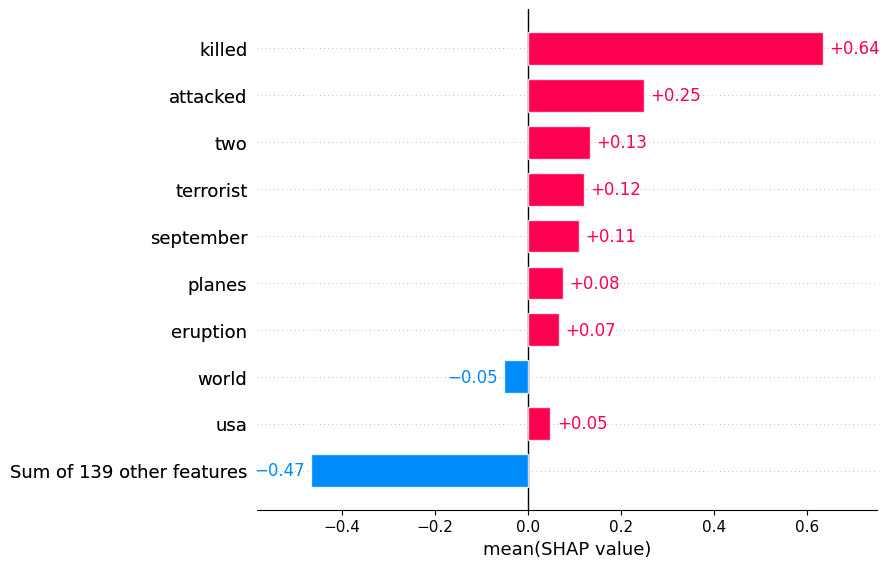

In [13]:
# 2. Visualisation globale : Quels sont les mots qui pèsent le plus sur l'ensemble de l'échantillon ?

shap.plots.bar(shap_values[:, :, "LABEL_1"].mean(0))

##### **2. Transformers Interpret (Heatmaps visuelles)**

In [18]:
from transformers_interpret import SequenceClassificationExplainer

# Initialisation de l'explainer (plus simple et très visuel)
cls_explainer = SequenceClassificationExplainer(model, tokenizer)

# Test sur un tweet spécifique (ex: un vrai tweet de catastrophe ou un piège)
test_tweet = X_test.iloc[0] # Ou n'importe quel texte personnalisé
word_attributions = cls_explainer(test_tweet)

print(f"Tweet analysé : {test_tweet}")
print(f"Classe prédite : {cls_explainer.predicted_class_name}")

# Affichage de la Heatmap
cls_explainer.visualize()

Tweet analysé : usasupportsterrorist out of the terrorist that attacked americans on september by flying planes into the world
Classe prédite : LABEL_1


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,LABEL_1 (0.67),LABEL_1,3.24,[CLS] usa ##su ##pp ##ort ##ster ##ror ##ist out of the terrorist that attacked americans on september by flying planes into the world [SEP]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,LABEL_1 (0.67),LABEL_1,3.24,[CLS] usa ##su ##pp ##ort ##ster ##ror ##ist out of the terrorist that attacked americans on september by flying planes into the world [SEP]
